In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
# from scipy.integrate import quad, trapz

# Quantum Circuits

In [2]:
alphas = np.loadtxt("data/dimer-model-qc/alpha.csv", delimiter=",")

L = len(alphas)

### Dimer Model

In [3]:
# Extract phases from results in other scripts

spins_4 = np.loadtxt("data/dimer-model-qc/4-spins.csv", delimiter=",")
spins_6 = np.loadtxt("data/dimer-model-qc/6-spins.csv", delimiter=",")
spins_8 = np.loadtxt("data/dimer-model-qc/8-spins.csv", delimiter=",")

berry_phases = [spins_4, spins_6, spins_8]

In [4]:
def errors(berry_phases):
    n_systems = len(berry_phases)
    l = len(berry_phases[0])

    exact_phases = np.zeros(l)
    exact_phases[0 : int(l / 2) + 1] = np.pi

    square_err = np.zeros((n_systems, l))
    abs_err = np.zeros((n_systems, l))

    for i in range(n_systems):
        for j in range(l):
            abs_err[i][j] = np.abs(exact_phases[j] - berry_phases[i][j])
            square_err[i][j] = (exact_phases[j] - berry_phases[i][j]) ** 2

        # Save to CSV
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-sq-error.csv",
            square_err[i],
            delimiter=",",
        )
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-abs-error.csv",
            abs_err[i],
            delimiter=",",
        )

        # FOr vis purposes
        square_err[i][10] = None

    return square_err, abs_err

In [5]:
sq_err, abs_err = errors(berry_phases)

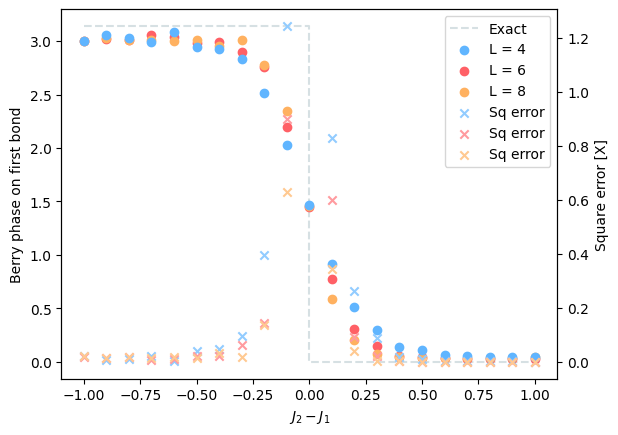

In [6]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

l = len(alphas)
exact_phases = np.zeros(l)
exact_phases[0 : int(l / 2) + 1] = np.pi

diff = alphas - 1


p0 = ax1.step(diff, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(diff, berry_phases[0], color=c4, label="L = 4", zorder=4)
p2 = ax1.scatter(diff, berry_phases[1], color=c6, label="L = 6", zorder=3)
p3 = ax1.scatter(diff, berry_phases[2], color=c8, label="L = 8", zorder=3)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p4 = ax2.scatter(diff, sq_err[0], color=c4e, marker="x", zorder=1, label="Sq error")
p5 = ax2.scatter(diff, sq_err[1], color=c6e, marker="x", zorder=1, label="Sq error")
p6 = ax2.scatter(diff, sq_err[2], color=c8e, marker="x", zorder=1, label="Sq error")

# Labels
ax1.set_xlabel("$J_2 - J_1$")
ax1.set_ylabel("Berry phase on first bond")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

### Tetra model

In [7]:
J1 = np.loadtxt("data/tetra-model-qc/n-100/j1.csv", delimiter=" ")
J2 = np.loadtxt("data/tetra-model-qc/n-100/j2.csv", delimiter=" ")

diff = J2 - J1
L = len(diff)

In [8]:
# Extract phases from results in other scripts

import pandas as pd

spins_4 = np.loadtxt("data/tetra-model-qc/n-100/berry.csv", delimiter=",")
spins_6 = np.loadtxt("data/tetra-model-qc/n-150/berry.csv", delimiter=",")
spins_8 = np.loadtxt("data/tetra-model-qc/n-200/berry.csv", delimiter=",")

berry_phases = [spins_4, spins_6, spins_8]

In [9]:
def errors(berry_phases):
    n_systems = len(berry_phases)
    l = len(berry_phases[0])

    exact_phases = np.zeros(l)
    exact_phases[0 : int(l / 2) + 1] = np.pi

    square_err = np.zeros((n_systems, l))
    abs_err = np.zeros((n_systems, l))

    for i in range(n_systems):
        for j in range(l):
            abs_err[i][j] = np.abs(exact_phases[j] - berry_phases[i][j])
            square_err[i][j] = (exact_phases[j] - berry_phases[i][j]) ** 2

        # Save to CSV
        # np.savetxt(
        #     f"data/dimer-model-qc/{(i*2)+4}-spins-sq-error.csv",
        #     square_err[i],
        #     delimiter=",",
        # )
        # np.savetxt(
        #     f"data/dimer-model-qc/{(i*2)+4}-spins-abs-error.csv",
        #     abs_err[i],
        #     delimiter=",",
        # )

        # FOr vis purposes
        square_err[i][10] = None
        square_err[i][11] = None

    return square_err, abs_err, exact_phases

In [10]:
sq_err, abs_err, exact_phases = errors(berry_phases)

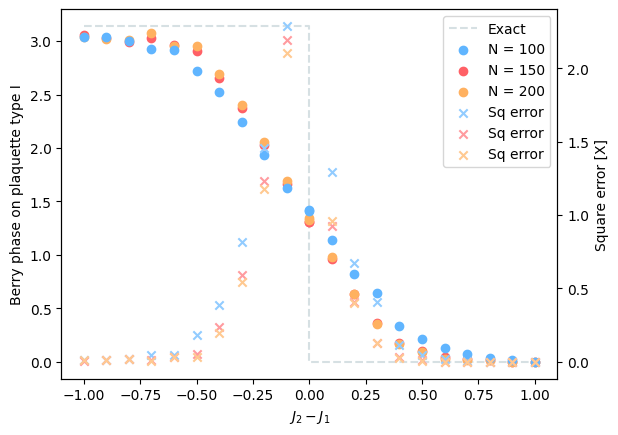

In [11]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

p0 = ax1.step(diff, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(diff, berry_phases[0], color=c4, label="N = 100", zorder=4)
p2 = ax1.scatter(diff, berry_phases[1], color=c6, label="N = 150", zorder=3)
p3 = ax1.scatter(diff, berry_phases[2], color=c8, label="N = 200", zorder=3)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p4 = ax2.scatter(diff, sq_err[0], color=c4e, marker="x", zorder=1, label="Sq error")
p5 = ax2.scatter(diff, sq_err[1], color=c6e, marker="x", zorder=1, label="Sq error")
p6 = ax2.scatter(diff, sq_err[2], color=c8e, marker="x", zorder=1, label="Sq error")

# Labels
ax1.set_xlabel("$J_2 - J_1$")
ax1.set_ylabel("Berry phase on plaquette type I")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

In [12]:
J1 = np.loadtxt("data/tetra-model-qc/links-1-2/J1.csv", delimiter=" ")
J2 = np.loadtxt("data/tetra-model-qc/links-1-2/J2.csv", delimiter=" ")

diff = J2 - J1
L = len(diff)

spins = np.loadtxt("data/tetra-model-qc/links-1-3/16-spins-n-150.csv", delimiter=",")

berry_phases = [spins]

def errors(berry_phases):
    n_systems = len(berry_phases)
    l = len(berry_phases[0])

    exact_phases = np.zeros(l)
    exact_phases[0 : int(l / 2) + 1] = np.pi

    square_err = np.zeros((n_systems, l))
    abs_err = np.zeros((n_systems, l))

    for i in range(n_systems):
        for j in range(l):
            abs_err[i][j] = np.abs(exact_phases[j] - berry_phases[i][j])
            square_err[i][j] = (exact_phases[j] - berry_phases[i][j]) ** 2

        # Save to CSV
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-sq-error.csv",
            square_err[i],
            delimiter=",",
        )
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-abs-error.csv",
            abs_err[i],
            delimiter=",",
        )

        # FOr vis purposes
        square_err[i][10] = None

    return square_err, abs_err, exact_phases

sq_err, abs_err, exact_phases = errors(berry_phases)

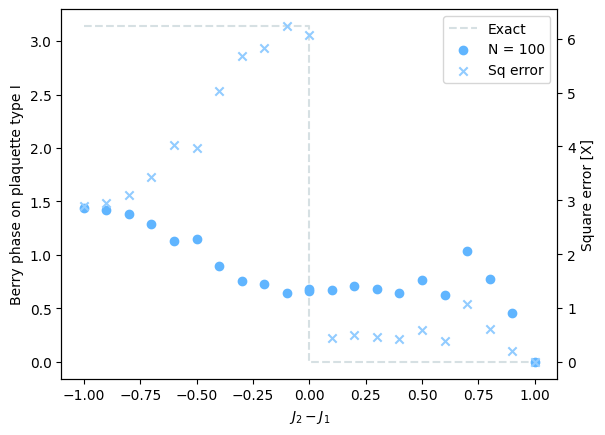

In [13]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

p0 = ax1.step(diff, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(diff, berry_phases[0], color=c4, label="N = 100", zorder=4)
# p2 = ax1.scatter(diff, berry_phases[1], color=c6, label="N = 200", zorder=3)
# p3 = ax1.scatter(diff, berry_phases[2], color=c8, label="N = 300", zorder=3)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p4 = ax2.scatter(diff, sq_err[0], color=c4e, marker="x", zorder=1, label="Sq error")
# p5 = ax2.scatter(diff, sq_err[1], color=c6e, marker="x", zorder=1, label="Sq error")
# p6 = ax2.scatter(diff, sq_err[2], color=c8e, marker="x", zorder=1, label="Sq error")

# Labels
ax1.set_xlabel("$J_2 - J_1$")
ax1.set_ylabel("Berry phase on plaquette type I")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

In [14]:
state_prep_error_300 = np.loadtxt("data/tetra-model-qc/links-1-2/eps-n-300.csv", delimiter=",")
state_prep_error_100 = np.loadtxt("data/tetra-model-qc/links-1-2/eps-n-100.csv", delimiter=",")
state_prep_error_200 = np.loadtxt("data/tetra-model-qc/links-1-2/eps-n-200.csv", delimiter=",")

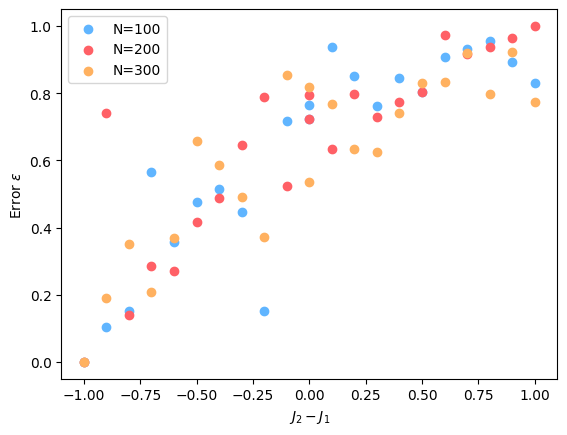

In [15]:
fig, ax = plt.subplots()
ax.scatter(diff, state_prep_error_100, color=c4, label='N=100')
ax.scatter(diff, state_prep_error_200, color=c6, label='N=200')
ax.scatter(diff, state_prep_error_300, color=c8, label='N=300')

ax.set_xlabel("$J_2-J_1$")
ax.set_ylabel(r"Error $\epsilon$")

ax.legend(loc="best")



# Wilson Loops (Classical algorithms)

In [16]:
import ast

def read_txt_data(file):
    with open(file, 'r') as f:
        content = f.read()

    return ast.literal_eval(content) 

In [17]:
e0_degen = read_txt_data('data/dimer-model-wilson/degen-n-100/e0.txt')
e1_degen = read_txt_data('data/dimer-model-wilson/degen-n-100/e1.txt')
twists = read_txt_data('data/dimer-model-wilson/degen-n-100/twists.txt')

e0_non_degen = read_txt_data('data/dimer-model-wilson/non-degen-n-100/e0.txt')
e1_non_degen = read_txt_data('data/dimer-model-wilson/non-degen-n-100/e1.txt')


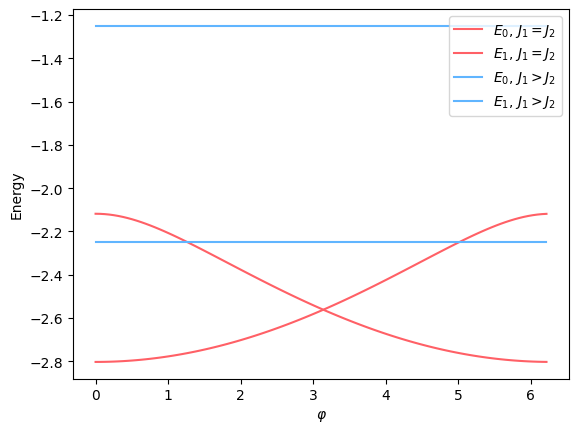

In [18]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

ax1.plot(twists, e0_degen[0], label="$E_0$, $J_1 = J_2$", c=c6)
ax1.plot(twists, e1_degen[0], label="$E_1$, $J_1 = J_2$", c=c6)
ax1.plot(twists, e0_non_degen[0], label="$E_0$, $J_1 > J_2$", c=c4)
ax1.plot(twists, e1_non_degen[0], label="$E_1$, $J_1 > J_2$", c=c4)


# Labels
ax1.set_xlabel(r"$\varphi$")
ax1.set_ylabel("Energy")
ax1.tick_params(axis="y")

# Legend
handles, labels = ax1.get_legend_handles_labels()

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

In [19]:
berry_4 = np.loadtxt("data/tetra-unitary/4-n-150.csv", delimiter=" ")
berry_16 = np.loadtxt("data/tetra-unitary/16-n-150.csv", delimiter=" ")
J2 = np.loadtxt("data/tetra-unitary/alphas.csv", delimiter=" ")
L = len(alphas)

J1 = 1

diff = J2 - J1

berry_phases = [berry_4, berry_16]


def errors(berry_phases):
    n_systems = len(berry_phases)
    l = len(berry_phases[0])

    exact_phases = np.zeros(l)
    exact_phases[0 : int(l / 2) + 1] = np.pi

    square_err = np.zeros((n_systems, l))
    abs_err = np.zeros((n_systems, l))

    for i in range(n_systems):
        for j in range(l):
            abs_err[i][j] = np.abs(exact_phases[j] - berry_phases[i][j])
            square_err[i][j] = (exact_phases[j] - berry_phases[i][j]) ** 2

        # Save to CSV
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-sq-error.csv",
            square_err[i],
            delimiter=",",
        )
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-abs-error.csv",
            abs_err[i],
            delimiter=",",
        )

        # FOr vis purposes
        square_err[i][10] = None

    return square_err, abs_err, exact_phases


sq_err, abs_err, exact_phases = errors(berry_phases)

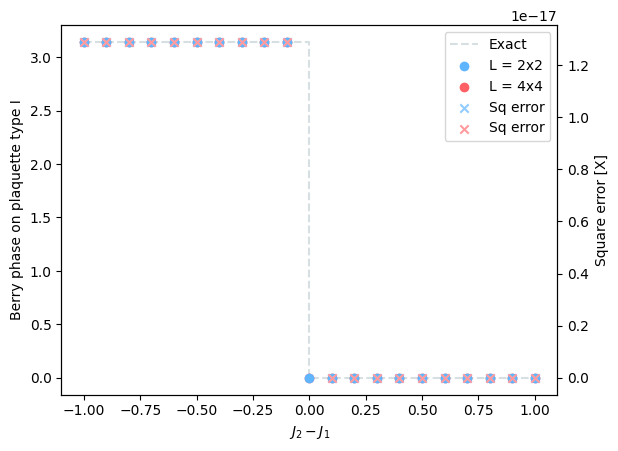

In [20]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

p0 = ax1.step(diff, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(diff, berry_phases[0], color=c4, label="L = 2x2", zorder=4)
p2 = ax1.scatter(diff, berry_phases[1], color=c6, label="L = 4x4", zorder=3)
# p3 = ax1.scatter(diff, berry_phases[2], color=c8, label="N = 300", zorder=3)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p4 = ax2.scatter(diff, sq_err[0], color=c4e, marker="x", zorder=1, label="Sq error")
p5 = ax2.scatter(diff, sq_err[1], color=c6e, marker="x", zorder=1, label="Sq error")
# p6 = ax2.scatter(diff, sq_err[2], color=c8e, marker="x", zorder=1, label="Sq error")

# Labels
ax1.set_xlabel("$J_2 - J_1$")
ax1.set_ylabel("Berry phase on plaquette type I")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

# Tetra degeneracies

In [21]:
dc = 2 * np.pi / 100
angles = np.arange(0, 2 * np.pi + dc, dc)
twists = np.cos(angles / 2)
L = len(angles)

In [22]:
energies = []
J = 1

# 1, 2
energies.append(4 * J * np.ones(L))
energies.append(4 * J * np.ones(L))

# 3, 4
energies.append(np.zeros(L))
energies.append(np.zeros(L))

# 5, 6
E5 = -2 * J * np.sqrt(2 - 2 * np.abs(twists))
energies.append(E5)
energies.append(E5)

# 7, 8
E7 = 2 * J * np.sqrt(2 - 2 * np.abs(twists))
energies.append(E7)
energies.append(E7)

# 9, 10
E9 = -2 * J * np.sqrt(2 + 2 * np.abs(twists))
energies.append(E9)
energies.append(E9)

# 11, 12
E11 = 2 * J * np.sqrt(2 + 2 * np.abs(twists))
energies.append(E11)
energies.append(E11)

# 13
E13 = -2 * J - 2 * J * np.sqrt(5 - 4 * np.abs(twists))
energies.append(E13)

# 14
E14 = -2 * J + 2 * J * np.sqrt(5 - 4 * np.abs(twists))
energies.append(E14)

# 15
E15 = -2 * J - 2 * J * np.sqrt(5 + 4 * np.abs(twists))
energies.append(E15)

# 16
E16 = -2 * J + 2 * J * np.sqrt(5 + 4 * np.abs(twists))
energies.append(E16)

/var/folders/xr/9754bxf57zvg208710lnn4m80000gn/T/ipykernel_56043/929413787.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


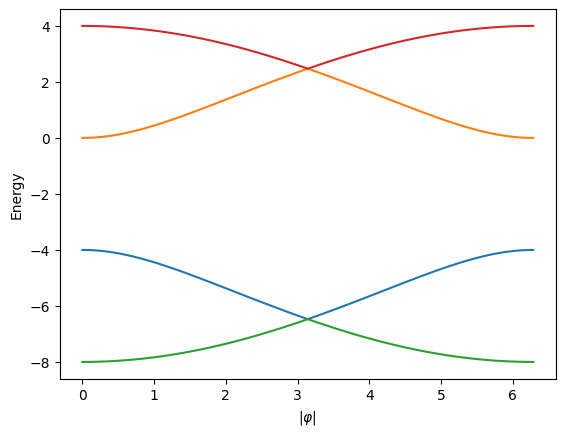

In [23]:
fig, ax = plt.subplots()

for energy in energies[12:16]:
    ax.plot(angles, energy)

ax.set_xlabel(r"$|\varphi|$")
ax.set_ylabel('Energy')
fig.show()